/tmp/ipython-input-622914002.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=labeled_df, order=label_order, palette=label_colors)


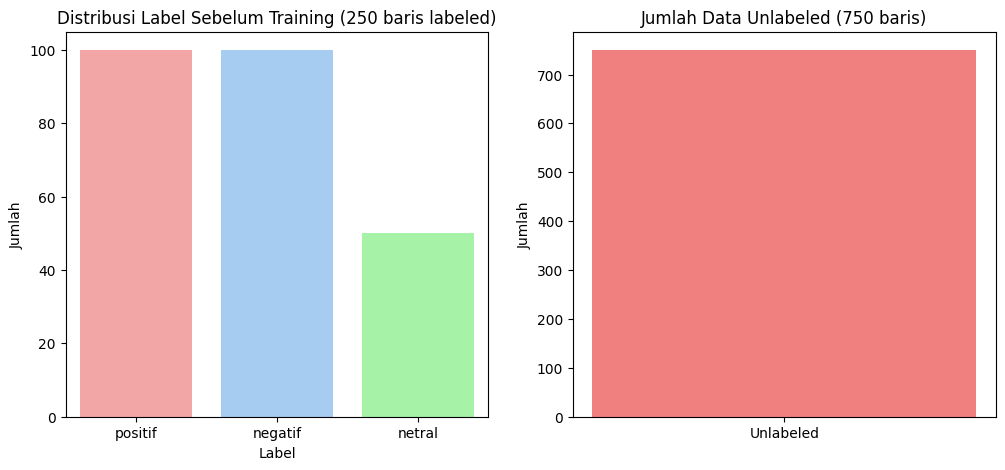

/tmp/ipython-input-622914002.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=pseudo_labeled_df, order=label_order, palette=label_colors)


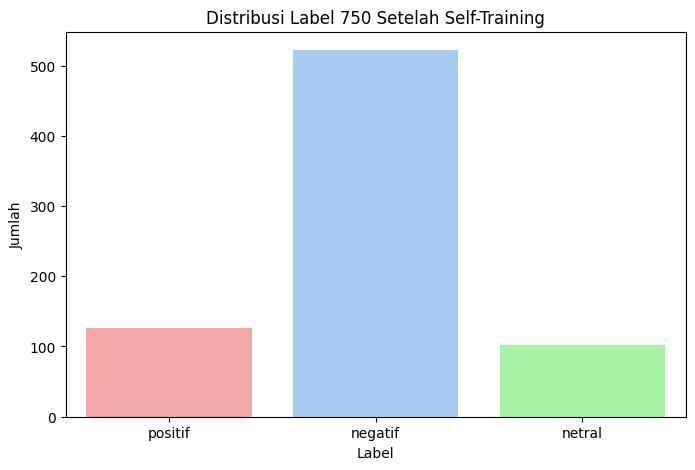

/tmp/ipython-input-622914002.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=df, order=label_order, palette=label_colors)


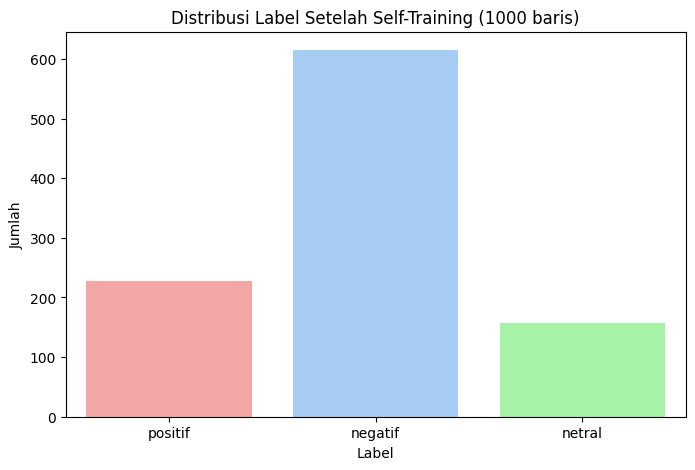

Selesai


In [ ]:
import pandas as pd
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.semi_supervised import SelfTrainingClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Baca file
df = pd.read_csv("/content/Data Label Manual.csv", sep=';', encoding='utf-8')

# 2. Pastikan Tokens_Final berupa string
def join_tokens(x):
    if isinstance(x, str):
        try:
            x_eval = ast.literal_eval(x)
            if isinstance(x_eval, list):
                return ' '.join(x_eval)
            else:
                return str(x)
        except:
            return str(x)
    elif isinstance(x, list):
        return ' '.join(x)
    else:
        return str(x)

df['Tokens_Final'] = df['Tokens_Final'].apply(join_tokens)

# 3. Visualisasi distribusi sebelum training
labeled_df = df[df['Label'].notna()]
unlabeled_df = df[df['Label'].isna()]

label_order = ['positif', 'negatif', 'netral']
label_colors = {'positif':'#FF9999', 'negatif':'#99CCFF', 'netral':'#99FF99'}

plt.figure(figsize=(12,5))

# Plot labeled 250
plt.subplot(1,2,1)
sns.countplot(x='Label', data=labeled_df, order=label_order, palette=label_colors)
plt.title("Distribusi Label Sebelum Training (250 baris labeled)")
plt.ylabel("Jumlah")

# Plot jumlah unlabeled 750
plt.subplot(1,2,2)
plt.bar(['Unlabeled'], [len(unlabeled_df)], color='lightcoral')
plt.title("Jumlah Data Unlabeled (750 baris)")
plt.ylabel("Jumlah")

plt.show()

# 4. Siapkan label untuk self-training
y = df['Label'].copy()
y[df['Label'].isna()] = -1

# 5. Vectorize teks
vectorizer = TfidfVectorizer()
X_vec = vectorizer.fit_transform(df['Tokens_Final'])

# 6. SelfTrainingClassifier dengan threshold
base_clf = LogisticRegression(max_iter=1000, class_weight='balanced')
self_train = SelfTrainingClassifier(base_clf, criterion='threshold', threshold=0.8, max_iter=10)

# 7. Fit
self_train.fit(X_vec, y)

# 8. Prediksi label untuk semua
df['Label'] = self_train.predict(X_vec)

# 9. Buat subset 750 baris
pseudo_labeled_df = df[df.index.isin(unlabeled_df.index)]

# Visualisasi distribusi 750
plt.figure(figsize=(8,5))
sns.countplot(x='Label', data=pseudo_labeled_df, order=label_order, palette=label_colors)
plt.title("Distribusi Label 750 Setelah Self-Training")
plt.ylabel("Jumlah")
plt.show()

# Visualisasi distribusi semua 1000 baris
plt.figure(figsize=(8,5))
sns.countplot(x='Label', data=df, order=label_order, palette=label_colors)
plt.title("Distribusi Label Setelah Self-Training (1000 baris)")
plt.ylabel("Jumlah")
plt.show()

# 10. Simpan hasil
df.to_csv("/content/Label Self Training.csv", sep=';', index=False, encoding='utf-8')

print("Selesai")
